# Feature Store de Telemetria de Rede

Este notebook documenta a construção de uma *feature store* a partir da
telemetria gerada pelo protótipo Mininet, disponível em `prototipo/relatorios/`.

O cenário experimental compreende **quatro caminhos concorrentes** entre os
switches `s1` e `s6`. Cada caminho dispõe de um par de hosts dedicado à medição
de latência, de modo que as rotas sejam observadas de forma independente. O
tráfego de carga consiste em um fluxo iperf UDP de 20 Mbps entre `h10` e `h60`.

## Modelo de dados

A store organiza-se em *feature groups* independentes, cada um definido em seu
próprio grão e compartilhando a chave de entidade canônica
`(run_id, rota_id, ts_epoch)`:

| feature group | grão | conteúdo |
|---|---|---|
| `fg_latencia` | (run, rota, ts) | RTT medido por ping |
| `fg_banda_interface` | (run, rota, interface, ts) | taxa e utilização por interface |
| `fg_banda_rota` | (run, rota, ts) | gargalo e agregados do caminho |
| `consolidado` | (run, rota, ts) | junção, features de janela e alvo |
| `dim_rota` | (rota) | atributos fixos do caminho (dimensão) |

Latência e banda não requerem coabitação em uma única tabela; a chave comum é
condição suficiente para a junção. Esta é realizada sob demanda pela função
`get_features`, e a tabela consolidada constitui o artefato derivado consumido
pelo notebook de aprendizado de máquina.

## Organização

 1. Importação
 2. Alinhamento temporal entre os dois relógios
 3. Topologia: capacidade das interfaces e dimensão das rotas
 4. Ingestão da banda
 5. Ingestão da latência
 6. Agregação da banda no grão da rota
 7. Consolidação e features de janela deslizante
 8. Persistência em CSV
 9. Descrição da feature store construída
10. Verificação
11. Visualização de validação
12. Consulta à store
13. Limitações desta coleta

## 1. Importação

A lógica de processamento reside em `feature_store/pipeline.py`, o que permite
sua verificação por asserções. Este notebook cumpre as funções de documentação
e validação visual.

A célula seguinte localiza a raiz do projeto a partir do diretório de trabalho
corrente e redefine o diretório ativo. O procedimento é necessário porque os
caminhos relativos empregados (`prototipo/relatorios`, `datasets/D*`) dependem
do diretório de inicialização do kernel, que difere entre `jupyter nbconvert`,
Jupyter Lab e a extensão Jupyter do VSCode — nesta última, o padrão é
`${fileDirname}`.

In [1]:
import os
import sys
from pathlib import Path


def raiz_do_projeto(marcadores=('prototipo', 'feature_store')):
    # Percorre o cwd e seus ancestrais até localizar os diretórios marcadores
    candidatos = [Path.cwd(), *Path.cwd().parents]
    for candidato in candidatos:
        if all((candidato / marcador).is_dir() for marcador in marcadores):
            return candidato
    raise RuntimeError(
        f'raiz do projeto não encontrada a partir de {Path.cwd()}. '
        f'Esperado um diretório contendo {marcadores}.'
    )


RAIZ = raiz_do_projeto()
os.chdir(RAIZ)
if str(RAIZ / 'feature_store') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'feature_store'))

print(f'raiz do projeto : {RAIZ}')
print(f'interpretador   : {sys.executable}')
print(f'python          : {sys.version.split()[0]}')

raiz do projeto : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets
interpretador   : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets/.venv/bin/python
python          : 3.14.0


In [2]:
import glob

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import pipeline as fs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 80)

print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 3.0.5 | numpy 2.5.2


## 2. Alinhamento temporal

O alinhamento entre as duas fontes é pré-condição para a consolidação, e sua
necessidade decorre de duas características dos dados de origem.

A primeira é a divergência de escala temporal. O protótipo registra a latência
por meio de `datetime.fromtimestamp(...).strftime(...)` (`relatorios.py:47`),
que produz hora local sem indicação de fuso e descarta o *epoch*. A banda, por
sua vez, provém do `bwm-ng` e preserva o *epoch* original. As duas séries
situam-se, portanto, em escalas distintas: uma junção direta por *timestamp*
resulta em zero registros contendo ambas as métricas.

A segunda é a presença de múltiplas execuções em um mesmo arquivo. O `bwm-ng`
abre o arquivo de saída em modo *append* (`telemetria.py:310`), de modo que
coletas sucessivas se acumulam. Os arquivos `banda_raw_*.csv` contêm duas
execuções, separadas por um intervalo sem amostras.

O arquivo `eventos.txt` permite resolver ambas as questões. Nele são registrados
os instantes BEGIN e END na mesma hora local da latência, ao passo que o
`bwm-ng` registra *epoch* — o arquivo constitui, assim, uma ponte entre as duas
escalas. Da comparação entre o evento BEGIN de banda e a primeira amostra de
cada execução candidata deriva-se o deslocamento, e a execução cujo resíduo é
mínimo é identificada como válida.

Cabe registrar que o alinhamento por *tempo relativo* — segundos decorridos
desde o início de cada fonte — não é adequado neste caso, pois associaria o
instante inicial da banda, pertencente à execução residual, ao instante inicial
da latência, deslocando as séries.

In [3]:
alinhamento = fs.inferir_alinhamento()

print(f"deslocamento inferido : {alinhamento['offset_s']} s "
      f"({alinhamento['offset_s'] // 3600} h)")
print(f"resíduo               : {alinhamento['residuo_s']:.0f} s")
print(f"execução válida       : {alinhamento['run_id']}")
print(f"janela (epoch)        : {alinhamento['t_ini']} .. {alinhamento['t_fim']}")
print(f"janela (UTC)          : {pd.to_datetime(alinhamento['t_ini'], unit='s')} .. "
      f"{pd.to_datetime(alinhamento['t_fim'], unit='s')}")
print()
print("candidatos avaliados (resíduo em relação à hora inteira):")
for candidato in alinhamento['candidatos']:
    print(f"  execução {candidato['run_id']}: resíduo {candidato['residuo_s']:6.0f} s  "
          f"epoch {candidato['t_ini']}..{candidato['t_fim']}")

deslocamento inferido : 25200 s (7 h)
resíduo               : 0 s
execução válida       : 1
janela (epoch)        : 1787019210 .. 1787019239
janela (UTC)          : 2026-08-18 02:13:30 .. 2026-08-18 02:13:59

candidatos avaliados (resíduo em relação à hora inteira):
  execução 0: resíduo     59 s  epoch 1787019151..1787019182
  execução 1: resíduo      0 s  epoch 1787019210..1787019239


A execução descartada apresenta resíduo de 59 s, enquanto a execução válida
apresenta resíduo nulo. O deslocamento não é fixado no código: coletas
provenientes de máquinas com outro fuso são tratadas pelo mesmo cálculo. Caso a
premissa de diferença inteira de horas não se verifique, `inferir_alinhamento`
levanta exceção, em vez de produzir um alinhamento incorreto de forma
silenciosa.

## 3. Topologia

Desta etapa resultam a capacidade de cada interface, o atraso configurado por
enlace e o caminho percorrido por cada rota.

A numeração das interfaces reproduz a ordem dos `addLink` em `topologia.py`, que
corresponde à ordem dos enlaces em `config.json`. O método
`topologia.get_interfaces_links()` resolve essa correspondência de forma mais
robusta, por meio de `Topo.port()`, porém requer uma instância ativa de `Topo` e
não se aplica à leitura dos relatórios fora da execução do protótipo.

In [4]:
topologia = fs.carregar_topologia()

print("capacidade por interface (Mbps), enlaces inter-switch:")
for interface, capacidade in sorted(topologia['capacidade_por_interface'].items()):
    if capacidade == 100.0:
        print(f"  {interface}: {capacidade}")

print()
dim_rota = fs.metadados_das_rotas(topologia)
dim_rota

capacidade por interface (Mbps), enlaces inter-switch:
  s1-eth1: 100.0
  s1-eth2: 100.0
  s2-eth1: 100.0
  s2-eth2: 100.0
  s2-eth3: 100.0
  s3-eth1: 100.0
  s3-eth2: 100.0
  s4-eth1: 100.0
  s4-eth2: 100.0
  s5-eth1: 100.0
  s5-eth2: 100.0
  s5-eth3: 100.0
  s6-eth1: 100.0
  s6-eth2: 100.0



,rota_id,caminho,n_links_sw,atraso_cfg_ms
0,h11_h61,h11-s1-s2-s3-s6-h61,3,24.0
1,h12_h62,h12-s1-s2-s5-s6-h62,3,34.0
2,h13_h63,h13-s1-s4-s5-s6-h63,3,20.0
3,h14_h64,h14-s1-s4-s5-s2-s3-s6-h64,5,18.0


### Distinção entre dimensão e features

O atributo `atraso_cfg_ms` corresponde ao RTT teórico do caminho, obtido como
duas vezes a soma dos atrasos configurados nos enlaces, e `n_links_sw` indica a
quantidade de enlaces inter-switch. Ambos são úteis à interpretação dos
resultados: a rota `h14_h64`, por exemplo, é a mais longa em número de saltos
(cinco enlaces) e, simultaneamente, a de menor atraso configurado (18 ms), o que
evidencia que extensão e atraso não são equivalentes nesta topologia.

Tais atributos, entretanto, **não constituem features da série temporal**. Como
a topologia permanece inalterada ao longo de uma coleta, essas colunas
apresentam variância nula dentro de cada rota e são função determinística de
`rota_id`. Incorporadas à matriz de treinamento, atuariam como identificadores
da rota, permitindo ao modelo distingui-las sem inferir qualquer informação
sobre o estado da rede.

Pelo mesmo motivo, duas features derivadas foram excluídas do conjunto:
`latencia_por_salto` (`latencia / n_links_sw`) e `folga_vs_atraso_cfg`
(`latencia - atraso_cfg_ms`). Por consistirem na latência escalada ou deslocada
por uma constante da rota, sua correlação com `latencia_ms` dentro de cada rota
é exatamente `1.0`, conforme se verifica a seguir.

A store separa, portanto, a **dimensão** (`dim_rota.csv`, atributos fixos) dos
**fatos** (os feature groups, séries temporais). A recuperação conjunta, quando
o objetivo for a comparação entre rotas, faz-se por
`get_features(incluir_dim_rota=True)`.

In [5]:
# Verificação da redundância das normalizações pela topologia
amostra = fs.get_features(incluir_dim_rota=True)
amostra = amostra[amostra.latencia_ms.notna()].copy()
amostra['latencia_por_salto'] = amostra.latencia_ms / amostra.n_links_sw
amostra['folga_vs_atraso_cfg'] = amostra.latencia_ms - amostra.atraso_cfg_ms

print("correlação com latencia_ms, dentro de cada rota:")
for derivada in ['latencia_por_salto', 'folga_vs_atraso_cfg']:
    correlacoes = amostra.groupby('rota_id').apply(
        lambda g: g[derivada].corr(g.latencia_ms), include_groups=False)
    print(f"  {derivada:22s} {correlacoes.round(6).to_dict()}")

correlação com latencia_ms, dentro de cada rota:
  latencia_por_salto     {'h11_h61': 1.0, 'h12_h62': 1.0, 'h13_h63': 1.0, 'h14_h64': 1.0}
  folga_vs_atraso_cfg    {'h11_h61': 1.0, 'h12_h62': 1.0, 'h13_h63': 1.0, 'h14_h64': 1.0}


## 4. Ingestão da banda

A ingestão parte dos arquivos `banda_raw_rota_*.csv`, saída não processada do
`bwm-ng`, e não dos `banda_tratada_*.csv`, por duas razões.

A primeira é a perda de uma amostra: `parser_banda.py:17` invoca `read_csv` sem
`header=None` e o `bwm-ng` não emite linha de cabeçalho, de modo que a primeira
linha de dados é interpretada como nome de coluna.

A segunda diz respeito às unidades: a função `toMbps` divide por `1 << 20`,
resultando em Mibit/s, grandeza subtraída de uma capacidade de 100 Mbit/s
decimal definida pelo TCLink. A conversão adotada nesta etapa emprega `1e6`,
coerente com o parâmetro `bw=100`.

A etapa descarta ainda a linha agregada `total` e restringe os dados à janela da
execução válida.

In [6]:
fg_banda_interface = fs.ingerir_banda(alinhamento, topologia)

print(f"dimensões: {fg_banda_interface.shape}")
print("interfaces por rota:")
for rota, grupo in fg_banda_interface.groupby('rota_id'):
    print(f"  {rota}: {sorted(grupo.interface.unique())}")

fg_banda_interface.head()

dimensões: (420, 8)
interfaces por rota:
  h11_h61: ['s1-eth1', 's2-eth2', 's3-eth2']
  h12_h62: ['s1-eth1', 's2-eth3', 's5-eth3']
  h13_h63: ['s1-eth2', 's4-eth2', 's5-eth3']
  h14_h64: ['s1-eth2', 's2-eth2', 's3-eth2', 's4-eth2', 's5-eth1']


,run_id,rota_id,interface,ts_epoch,taxa_Mbps,capacidade_Mbps,banda_disp_Mbps,util_pct
0,1,h11_h61,s1-eth1,1787019210,0.000000,100.0,100.000000,0.000000
1,1,h11_h61,s2-eth2,1787019210,0.000000,100.0,100.000000,0.000000
2,1,h11_h61,s3-eth2,1787019210,0.000000,100.0,100.000000,0.000000
3,1,h11_h61,s1-eth1,1787019211,20.331806,100.0,79.668194,20.331806
4,1,h11_h61,s2-eth2,1787019211,20.320016,100.0,79.679984,20.320016


As interfaces repetem-se entre rotas: `s1-eth1` integra duas delas, `s2-eth2`
igualmente, e assim sucessivamente. Essa sobreposição caracteriza o cenário como
*path-aware*, uma vez que o tráfego em um caminho afeta os demais caminhos que
compartilham enlaces com ele.

## 5. Ingestão da latência

Os arquivos de latência são delimitados por tabulação e apresentam o valor
`None` nas primeiras amostras, durante a inicialização do `ping`. A conversão
para *epoch* incorpora o deslocamento inferido na Seção 2.

Quanto à implementação, a conversão emprega
`(serie - Timestamp('1970-01-01')) // Timedelta('1s')`, e não
`astype('int64') // 10**9`. O pandas utilizado neste ambiente adota
`datetime64[us]`, e não `[ns]`, de forma que a divisão por `10**9` produziria
valores incorretos sem emissão de erro.

In [7]:
fg_latencia = fs.ingerir_latencia(alinhamento)

print(f"dimensões: {fg_latencia.shape}")
print("amostras sem medida (inicialização do ping): "
      f"{int(fg_latencia.latencia_ms.isna().sum())}")
fg_latencia.head()

dimensões: (121, 4)
amostras sem medida (inicialização do ping): 5


,run_id,rota_id,ts_epoch,latencia_ms
0,1,h11_h61,1787019209,NaN
1,1,h11_h61,1787019210,NaN
2,1,h11_h61,1787019211,50.978306
3,1,h11_h61,1787019212,29.785503
4,1,h11_h61,1787019213,51.230175


## 6. Agregação da banda no grão da rota

O atributo `gargalo_Mbps`, definido como a menor banda disponível entre as
interfaces do caminho, constitui a feature central desta etapa, por ser a
grandeza que limita a vazão útil da rota em cada instante.

In [8]:
fg_banda_rota = fs.agregar_por_rota(fg_banda_interface, topologia)

print(f"dimensões: {fg_banda_rota.shape}")
fg_banda_rota.head()

dimensões: (120, 6)


,run_id,rota_id,ts_epoch,gargalo_Mbps,banda_media_Mbps,util_max_pct
0,1,h11_h61,1787019210,100.000000,100.000000,0.000000
1,1,h11_h61,1787019211,79.668194,79.731075,20.331806
2,1,h11_h61,1787019212,79.316448,79.427440,20.683552
3,1,h11_h61,1787019213,79.587032,79.610424,20.412968
4,1,h11_h61,1787019214,79.402440,79.449648,20.597560


## 7. Consolidação e features de janela

A junção emprega a chave `(run_id, rota_id, ts_epoch)`, com `how='left'` a
partir da banda. Os instantes em que o ping não retornou medida permanecem como
`NaN` explícito, preservando a continuidade da série.

### Features de janela deslizante

O valor instantâneo não representa tendência nem estabilidade. Para três
janelas — 5 s (micro), 15 s (curta) e 30 s (longa) — derivam-se as seguintes
grandezas.

Da latência: `p95` (pior caso habitual), `jitter` (desvio padrão, indicador de
instabilidade) e `media`.

Da banda: `gargalo_min` (menor gargalo observado na janela), `banda_media` e
`utilizacao_media`.

### Deltas e features cruzadas

- `latencia_delta_micro_longa` — indicador de tendência; valores positivos e
  crescentes sinalizam congestionamento em formação
- `banda_delta_micro_longa` — severidade do gargalo corrente frente ao
  comportamento típico da coleta
- `bdp` — *Bandwidth-Delay Product* (`gargalo x latencia`), estimativa do
  volume de dados em trânsito

Todas as grandezas acima variam no tempo. Normalizações pela topologia foram
excluídas pelas razões expostas na Seção 3.

> **Observação sobre a janela longa.** A coleta dispõe de aproximadamente 30 s
> úteis, de modo que a janela de 30 s abrange praticamente todo o experimento.
> Ela representa o contexto da própria coleta, e não uma linha de base
> histórica. Em consequência, `latencia_delta_micro_longa` assume valor nulo nos
> primeiros segundos, quando ambas as janelas ainda abrangem as mesmas amostras.

In [9]:
view = fs.consolidar(fg_banda_rota, fg_latencia)
view = fs.calcular_features_janela(view)
view = fs.calcular_deltas_e_cross_features(view)
view = fs.derivar_alvo(view)

print(f"dimensões da tabela consolidada: {view.shape}")
print("registros com latência e banda simultâneas: "
      f"{int(view.latencia_ms.notna().sum())} de {len(view)}")
print()
view[['datetime_utc', 'rota_id', 'latencia_ms', 'gargalo_Mbps', 'util_max_pct',
      'latencia_jitter_micro_5s', 'bdp']].head(8)

dimensões da tabela consolidada: (120, 31)
registros com latência e banda simultâneas: 116 de 120



,datetime_utc,rota_id,latencia_ms,gargalo_Mbps,util_max_pct,latencia_jitter_micro_5s,bdp
0,2026-08-18 02:13:30,h11_h61,NaN,100.000000,0.000000,NaN,NaN
1,2026-08-18 02:13:31,h11_h61,50.978306,79.668194,20.331806,NaN,4061.349602
2,2026-08-18 02:13:32,h11_h61,29.785503,79.316448,20.683552,14.985575,2362.480298
3,2026-08-18 02:13:33,h11_h61,51.230175,79.587032,20.412968,12.309023,4077.257574
4,2026-08-18 02:13:34,h11_h61,66.472070,79.402440,20.597560,15.075777,5278.044536
5,2026-08-18 02:13:35,h11_h61,33.287741,78.814240,21.185760,14.959447,2623.547984
6,2026-08-18 02:13:36,h11_h61,47.454748,79.530688,20.469312,14.768731,3774.108762
7,2026-08-18 02:13:37,h11_h61,41.105758,79.184544,20.815456,12.408560,3254.940729


### A coluna `melhor_rota`

A função `derivar_alvo` produz a coluna `melhor_rota`, correspondente ao índice
(base 1) da rota de menor latência em cada instante, no mesmo formato dos
arquivos `rotulos_*.txt` de `datasets/`, assegurando compatibilidade com o
notebook de aprendizado de máquina.

Cabe uma ressalva quanto a esse alvo. Nos dez conjuntos de dados disponíveis em
`datasets/`, o rótulo corresponde identicamente a `argmin(latencia) + 1` no
mesmo instante, com concordância de `1.0000` em todos eles. O alvo é, portanto,
função determinística de uma das features, e um classificador que receba as
latências resolve um problema trivial. A verificação a seguir documenta esse
resultado.

A feature store não corrige o vazamento. Sua contribuição consiste em
disponibilizar a banda como preditor independente, o que viabiliza formulações
sem vazamento — por exemplo, a previsão da melhor rota em `t + k` a partir das
features observadas em `t`.

In [10]:
for pasta in sorted(glob.glob('datasets/D*')):
    csvs = glob.glob(os.path.join(pasta, 'latencia_rotas_*.csv'))
    rotulos = glob.glob(os.path.join(pasta, 'rotulos_*.txt')) + \
              glob.glob(os.path.join(pasta, 'labels_*.txt'))
    if not csvs or not rotulos:
        continue
    latencias = pd.read_csv(csvs[0])
    y = np.loadtxt(rotulos[0], dtype=int)
    argmin = latencias.iloc[:, 1:].values.argmin(axis=1) + 1
    n = min(len(y), len(argmin))
    print(f"  {os.path.basename(pasta):5s} n={n:5d}  "
          f"rótulo == argmin(latência): {(y[:n] == argmin[:n]).mean():.4f}")

  D1    n= 3599  rótulo == argmin(latência): 1.0000
  D1b   n= 3599  rótulo == argmin(latência): 1.0000
  D2    n= 3660  rótulo == argmin(latência): 1.0000
  D2b   n= 3650  rótulo == argmin(latência): 1.0000
  D3    n= 3663  rótulo == argmin(latência): 1.0000
  D3a   n= 3663  rótulo == argmin(latência): 1.0000
  D3b   n= 3658  rótulo == argmin(latência): 1.0000
  D4    n= 3851  rótulo == argmin(latência): 1.0000
  D4a   n= 3851  rótulo == argmin(latência): 1.0000
  D4b   n= 3770  rótulo == argmin(latência): 1.0000


## 8. Persistência

A store é gravada em CSV, segundo dois layouts.

O layout **longo** (`data/csv/`) contém um arquivo por feature group, em que
cada registro corresponde a uma observação no grão da respectiva tabela.
Constitui a camada canônica, recuperada por `get_features()`.

O layout **largo** (`data/csv_ml/`) compreende `latencia_rotas_h1_h6.csv`,
`banda_rotas_h1_h6.csv` e `rotulos_h1_h6.txt`, com uma coluna por rota e um
registro por instante. Reproduz o layout de `datasets/D*`, de modo que o
notebook de aprendizado de máquina o consuma sem adaptação.

O layout largo contempla apenas os instantes providos de rótulo, de forma que o
arquivo de features e o de rótulos apresentem contagens iguais de registros —
`np.loadtxt` com `dtype=int` não admite campo vazio.

In [11]:
gerados = fs.exportar_csv(fg_latencia, fg_banda_interface, fg_banda_rota,
                          view, dim_rota)

for caminho in gerados:
    print(f"  {caminho:52s} {os.path.getsize(caminho):>8,} bytes")

  feature_store/data/csv/fg_latencia.csv                  4,704 bytes
  feature_store/data/csv/fg_banda_interface.csv          28,392 bytes
  feature_store/data/csv/fg_banda_rota.csv                6,861 bytes
  feature_store/data/csv/consolidado.csv                 53,386 bytes
  feature_store/data/csv/dim_rota.csv                       187 bytes
  feature_store/data/csv_ml/latencia_rotas_h1_h6.csv      2,744 bytes
  feature_store/data/csv_ml/banda_rotas_h1_h6.csv         1,893 bytes
  feature_store/data/csv_ml/rotulos_h1_h6.txt                58 bytes


### 8.1 Precisão e tipos na releitura

O formato CSV não preserva tipos, o que impõe dois cuidados.

Quanto à **precisão**, a escrita é exata: `to_csv` emprega a representação mais
curta que assegura round-trip. A perda ocorre na **leitura**, pois o parser C de
`read_csv` adota, por padrão, uma conversão mais rápida e menos precisa, com
erro na última casa decimal — da ordem de 1e-13 nas colunas de maior magnitude,
como `bdp`.

Quanto aos **tipos**, `datetime_utc` é recuperada como texto e `melhor_rota`
como ponto flutuante, em razão dos valores ausentes.

A função `pipeline.ler_csv` trata ambos os aspectos: aplica
`float_precision='round_trip'` e reconverte as colunas. A comparação a seguir
toma como referência o dataframe em memória.

In [12]:
numericas = [c for c in view.columns if pd.api.types.is_numeric_dtype(view[c])]


def pior_diferenca(quadro):
    return max(
        (view[c].astype('float64') - quadro[c].astype('float64')).abs().max()
        for c in numericas
    )


padrao = pd.read_csv('feature_store/data/csv/consolidado.csv')
correto = fs.ler_csv('feature_store/data/csv/consolidado.csv')

print(f"read_csv padrão : diferença {pior_diferenca(padrao)}")
print(f"fs.ler_csv      : diferença {pior_diferenca(correto)}")
print()
print("tipos recuperados por fs.ler_csv:")
for coluna in ['ts_epoch', 'datetime_utc', 'melhor_rota', 'rota_id']:
    print(f"  {coluna:14s} memória={str(view[coluna].dtype):16s} "
          f"read_csv={str(padrao[coluna].dtype):10s} ler_csv={correto[coluna].dtype}")

assert pior_diferenca(correto) == 0.0
assert correto.melhor_rota.dtype == 'Int64'
assert pd.api.types.is_datetime64_any_dtype(correto.datetime_utc)
print()
print("ler_csv reproduz os valores e os tipos da tabela em memória.")

read_csv padrão : diferença 4.547473508864641e-13
fs.ler_csv      : diferença 0.0

tipos recuperados por fs.ler_csv:
  ts_epoch       memória=int64            read_csv=int64      ler_csv=int64
  datetime_utc   memória=datetime64[s]    read_csv=str        ler_csv=datetime64[us]
  melhor_rota    memória=Int64            read_csv=float64    ler_csv=Int64
  rota_id        memória=str              read_csv=str        ler_csv=str

ler_csv reproduz os valores e os tipos da tabela em memória.


### 8.2 Compatibilidade com o notebook de aprendizado de máquina

A célula seguinte reproduz o procedimento de carga adotado em
`Análise_de_modelos_de_ML_para_previsão_de_caminhos.ipynb` sobre o layout largo
exportado, confirmando que este é consumido sem adaptação.

In [13]:
historico = pd.read_csv('feature_store/data/csv_ml/latencia_rotas_h1_h6.csv')
rotulos = np.loadtxt('feature_store/data/csv_ml/rotulos_h1_h6.txt',
                     comments='#', dtype=int)

latencia_por_rota = historico.iloc[:, 1:].values
datetimes_dt = pd.to_datetime(historico.iloc[:, 0].values)
temporal_features = np.column_stack([
    datetimes_dt.hour, datetimes_dt.minute, datetimes_dt.second,
    datetimes_dt.day, datetimes_dt.month, datetimes_dt.year,
])

print(f"latencia_por_rota : {latencia_por_rota.shape}")
print(f"temporal_features : {temporal_features.shape}")
print(f"rótulos           : {rotulos.shape}  classes={sorted(set(rotulos.tolist()))}")

assert len(rotulos) == len(historico)
print()
print("As contagens são compatíveis. O layout largo apresenta um registro a")
print("menos que a tabela consolidada, pois o primeiro segundo não dispõe de")
print("medida de latência e, por conseguinte, de rótulo.")

latencia_por_rota : (29, 4)
temporal_features : (29, 6)
rótulos           : (29,)  classes=[1, 3, 4]

As contagens são compatíveis. O layout largo apresenta um registro a
menos que a tabela consolidada, pois o primeiro segundo não dispõe de
medida de latência e, por conseguinte, de rótulo.


## 9. Descrição da feature store construída

Apresentam-se, nesta seção, o catálogo das tabelas, o conteúdo da tabela
consolidada, o dicionário de features e a caracterização das rotas.

In [14]:
catalogo = [
    ('fg_latencia',        'run, rota, ts',            fg_latencia),
    ('fg_banda_interface', 'run, rota, interface, ts', fg_banda_interface),
    ('fg_banda_rota',      'run, rota, ts',            fg_banda_rota),
    ('consolidado',        'run, rota, ts',            view),
    ('dim_rota',           'rota',                     dim_rota),
]

print(f"{'tabela':22s} {'grão':26s} {'registros':>10s} {'colunas':>8s}")
print('-' * 69)
for nome, grao, quadro in catalogo:
    print(f"{nome:22s} {grao:26s} {len(quadro):>10d} {quadro.shape[1]:>8d}")
print('-' * 69)
print(f"{'rotas':22s} {', '.join(sorted(view.rota_id.unique()))}")
print(f"{'janela':22s} {view.datetime_utc.min()} .. {view.datetime_utc.max()} UTC")
print(f"{'duração':22s} {view.tempo_relativo_s.max() + 1} s")

tabela                 grão                        registros  colunas
---------------------------------------------------------------------
fg_latencia            run, rota, ts                     121        4
fg_banda_interface     run, rota, interface, ts          420        8
fg_banda_rota          run, rota, ts                     120        6
consolidado            run, rota, ts                     120       31
dim_rota               rota                                4        4
---------------------------------------------------------------------
rotas                  h11_h61, h12_h62, h13_h63, h14_h64
janela                 2026-08-18 02:13:30 .. 2026-08-18 02:13:59 UTC
duração                30 s


In [15]:
# Tabela consolidada, na íntegra
view

,run_id,rota_id,ts_epoch,gargalo_Mbps,banda_media_Mbps,util_max_pct,latencia_ms,datetime_utc,tempo_relativo_s,latencia_p95_micro_5s,latencia_jitter_micro_5s,latencia_media_micro_5s,gargalo_min_micro_5s,banda_media_micro_5s,utilizacao_media_micro_5s,latencia_p95_curta_15s,latencia_jitter_curta_15s,latencia_media_curta_15s,gargalo_min_curta_15s,banda_media_curta_15s,utilizacao_media_curta_15s,latencia_p95_longa_30s,latencia_jitter_longa_30s,latencia_media_longa_30s,gargalo_min_longa_30s,banda_media_longa_30s,utilizacao_media_longa_30s,latencia_delta_micro_longa,banda_delta_micro_longa,bdp,melhor_rota
0,1,h11_h61,1787019210,100.000000,100.000000,0.000000,NaN,2026-08-18 02:13:30,0,NaN,NaN,NaN,100.000000,100.000000,0.000000,NaN,NaN,NaN,100.000000,100.000000,0.000000,NaN,NaN,NaN,100.000000,100.000000,0.000000,NaN,1.000000,NaN,<NA>
1,1,h11_h61,1787019211,79.668194,79.731075,20.331806,50.978306,2026-08-18 02:13:31,1,50.978306,NaN,50.978306,79.668194,89.865538,0.101659,50.978306,NaN,50.978306,79.668194,89.865538,0.101659,50.978306,NaN,50.978306,79.668194,89.865538,0.101659,0.000000,0.886527,4061.349602,3
2,1,h11_h61,1787019212,79.316448,79.427440,20.683552,29.785503,2026-08-18 02:13:32,2,49.918666,14.985575,40.381905,79.316448,86.386172,0.136718,49.918666,14.985575,40.381905,79.316448,86.386172,0.136718,49.918666,14.985575,40.381905,79.316448,86.386172,0.136718,0.000000,0.918161,2362.480298,4
3,1,h11_h61,1787019213,79.587032,79.610424,20.412968,51.230175,2026-08-18 02:13:33,3,51.204988,12.309023,43.997995,79.316448,84.692235,0.153571,51.204988,12.309023,43.997995,79.316448,84.692235,0.153571,51.204988,12.309023,43.997995,79.316448,84.692235,0.153571,0.000000,0.936526,4077.257574,4
4,1,h11_h61,1787019214,79.402440,79.449648,20.597560,66.472070,2026-08-18 02:13:34,4,64.185786,15.075777,49.616514,79.316448,83.643717,0.164052,64.185786,15.075777,49.616514,79.316448,83.643717,0.164052,64.185786,15.075777,49.616514,79.316448,83.643717,0.164052,0.000000,0.948265,5278.044536,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1,h14_h64,1787019235,99.996084,99.996710,0.003916,36.593751,2026-08-18 02:13:55,25,48.478651,13.037124,35.381799,99.996084,99.996880,0.000033,53.031450,12.881380,34.839015,78.561518,97.520896,0.062031,62.939213,14.740408,37.820971,78.561518,95.400176,0.115155,-2.439172,1.048175,3659.231804,3
116,1,h14_h64,1787019236,99.996867,99.996867,0.003133,23.167546,2026-08-18 02:13:56,26,48.478651,12.364314,35.880419,99.996084,99.996880,0.000033,53.031450,12.921093,33.422273,78.561518,98.048342,0.048840,62.927492,14.725726,37.257378,78.561518,95.570424,0.110891,-1.376959,1.046308,2316.682015,4
117,1,h14_h64,1787019237,99.996873,99.996873,0.003127,33.285864,2026-08-18 02:13:57,27,48.478651,10.571681,37.828980,99.996084,99.996877,0.000033,48.161425,10.016262,31.442257,78.561518,98.598188,0.035090,62.915771,14.459976,37.110285,78.561518,95.728511,0.106932,0.718695,1.044580,3328.482353,3
118,1,h14_h64,1787019238,99.996867,99.997180,0.003133,51.070977,2026-08-18 02:13:58,28,50.609816,11.503032,38.576662,99.996084,99.996900,0.000033,49.456913,11.212002,32.825009,80.110354,99.169691,0.020800,62.904049,14.432864,37.608881,78.561518,95.875707,0.103246,0.967781,1.042976,5106.937670,3


In [16]:
# Dicionário de features: tipo, preenchimento e faixa de valores
print(f"consolidado: {len(view)} registros x {view.shape[1]} colunas\n")

descricao = []
for coluna in view.columns:
    serie = view[coluna]
    if pd.api.types.is_numeric_dtype(serie):
        faixa = f"{serie.min():.4g} .. {serie.max():.4g}"
    elif pd.api.types.is_datetime64_any_dtype(serie):
        faixa = f"{serie.min()} .. {serie.max()}"
    else:
        faixa = f"{serie.nunique()} valores distintos"
    descricao.append({
        'coluna': coluna,
        'tipo': str(serie.dtype),
        'preenchidas': f"{serie.notna().sum()}/{len(serie)}",
        'faixa': faixa,
    })

print(pd.DataFrame(descricao).to_string(index=False))

consolidado: 120 registros x 31 colunas

                    coluna          tipo preenchidas                                      faixa
                    run_id         int64     120/120                                     1 .. 1
                   rota_id           str     120/120                        4 valores distintos
                  ts_epoch         int64     120/120                     1.787e+09 .. 1.787e+09
              gargalo_Mbps       float64     120/120                               78.53 .. 100
          banda_media_Mbps       float64     120/120                               78.83 .. 100
              util_max_pct       float64     120/120                                 0 .. 21.47
               latencia_ms       float64     116/120                             20.67 .. 88.02
              datetime_utc datetime64[s]     120/120 2026-08-18 02:13:30 .. 2026-08-18 02:13:59
          tempo_relativo_s         int64     120/120                                    0 .. 29

In [17]:
# Estatísticas descritivas das features que variam no tempo
variaveis = [c for c in view.columns
             if pd.api.types.is_numeric_dtype(view[c])
             and c not in ('run_id', 'ts_epoch', 'tempo_relativo_s', 'melhor_rota')]

view[variaveis].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
gargalo_Mbps,120.0,92.5118,9.8117,78.5282,79.7007,99.9961,99.9969,100.0000
banda_media_Mbps,120.0,95.6764,6.7658,78.8304,92.8576,99.9966,99.9969,100.0000
util_max_pct,120.0,7.4882,9.8117,0.0000,0.0031,0.0039,20.2993,21.4718
latencia_ms,116.0,44.2820,15.0203,20.6744,31.3225,45.2917,53.0239,88.0163
latencia_p95_micro_5s,116.0,57.1667,11.9865,25.5405,48.3784,53.9447,65.3623,86.1478
latencia_jitter_micro_5s,112.0,11.9066,4.8413,1.8750,8.9279,11.4802,14.4585,35.3610
latencia_media_micro_5s,116.0,44.8376,11.0729,22.6693,36.8180,43.2490,50.9247,76.4045
gargalo_min_micro_5s,120.0,90.2413,10.4123,78.5282,78.8746,99.9946,99.9961,100.0000
banda_media_micro_5s,120.0,95.4656,6.3808,79.2831,93.1130,99.9966,99.9969,100.0000
utilizacao_media_micro_5s,120.0,0.0785,0.0911,0.0000,0.0000,0.0000,0.1917,0.2075


In [18]:
# Caracterização das rotas no cenário coletado
retrato = view.groupby('rota_id').agg(
    latencia_media=('latencia_ms', 'mean'),
    latencia_p95=('latencia_ms', lambda s: s.quantile(0.95)),
    jitter_medio=('latencia_jitter_micro_5s', 'mean'),
    gargalo_medio=('gargalo_Mbps', 'mean'),
    gargalo_min=('gargalo_Mbps', 'min'),
    utilizacao_max=('util_max_pct', 'max'),
    bdp_medio=('bdp', 'mean'),
).round(3)
retrato = retrato.join(dim_rota.set_index('rota_id'))
print(retrato.to_string())

         latencia_media  latencia_p95  jitter_medio  gargalo_medio  gargalo_min  utilizacao_max  bdp_medio                    caminho  n_links_sw  atraso_cfg_ms
rota_id                                                                                                                                                         
h11_h61          41.769        57.329        10.487         89.997       78.814          21.186   3737.803        h11-s1-s2-s3-s6-h61           3           24.0
h12_h62          58.230        75.330        12.179         90.034       78.528          21.472   5183.746        h12-s1-s2-s5-s6-h62           3           34.0
h13_h63          38.854        56.011        10.875         99.997       99.995           0.005   3885.270        h13-s1-s4-s5-s6-h63           3           20.0
h14_h64          38.275        62.892        14.085         90.019       78.562          21.438   3398.003  h14-s1-s4-s5-s2-s3-s6-h64           5           18.0


## 10. Verificação

As asserções desta seção documentam os valores esperados e interrompem a
execução em caso de regressão do pipeline.

In [19]:
# 1. Alinhamento temporal
assert alinhamento['offset_s'] == 25200, alinhamento['offset_s']
assert alinhamento['residuo_s'] == 0, alinhamento['residuo_s']
assert (alinhamento['t_ini'], alinhamento['t_fim']) == (1787019210, 1787019239)

# 2. Contagens por tabela
assert fg_banda_interface.shape[0] == 420, fg_banda_interface.shape   # 14 ifaces x 30 s
assert fg_banda_rota.shape[0] == 120, fg_banda_rota.shape
assert len(view) == 120, len(view)
assert view.rota_id.value_counts().unique().tolist() == [30]

# 3. Cobertura da latência: os valores ausentes concentram-se no primeiro segundo
assert int(view.latencia_ms.notna().sum()) == 116, int(view.latencia_ms.notna().sum())
assert view[view.latencia_ms.isna()].ts_epoch.nunique() == 1

# 4. Ausência de colunas integralmente nulas
assert not [c for c in view.columns if view[c].isna().all()]

print("verificações estruturais: aprovadas")

verificações estruturais: aprovadas


In [20]:
# 5. Consistência física: h13_h63 é a única rota disjunta do caminho do iperf
utilizacao = view.groupby('rota_id').util_max_pct.max()
print("utilização máxima por rota (%):")
print(utilizacao.round(3).to_string())

assert utilizacao['h13_h63'] < 0.1, utilizacao['h13_h63']
for rota in ['h11_h61', 'h12_h62', 'h14_h64']:
    assert utilizacao[rota] > 20, (rota, utilizacao[rota])

print()
print("A rota h13_h63 (s1-s4-s5-s6) não compartilha enlaces com o tráfego iperf")
print("e permanece praticamente ociosa. As demais compartilham s1-eth1, s2-eth2")
print("ou s3-eth2 e absorvem a contenção resultante.")

utilização máxima por rota (%):
rota_id
h11_h61    21.186
h12_h62    21.472
h13_h63     0.005
h14_h64    21.438

A rota h13_h63 (s1-s4-s5-s6) não compartilha enlaces com o tráfego iperf
e permanece praticamente ociosa. As demais compartilham s1-eth1, s2-eth2
ou s3-eth2 e absorvem a contenção resultante.


In [21]:
# 6. Correspondência entre a latência medida e o atraso configurado.
# O atraso configurado é recuperado de dim_rota por junção, por ser atributo da
# rota e não da série temporal.
resumo = view.groupby('rota_id').agg(
    latencia_media=('latencia_ms', 'mean'),
    gargalo_medio=('gargalo_Mbps', 'mean'),
).round(2)
resumo = resumo.join(dim_rota.set_index('rota_id')[['atraso_cfg_ms']])
resumo['folga'] = (resumo.latencia_media - resumo.atraso_cfg_ms).round(2)
print(resumo.to_string())

assert resumo.latencia_media.idxmax() == 'h12_h62'   # maior atraso configurado
print()
print("A rota de maior atraso configurado (h12_h62, 34 ms) apresenta também a")
print("maior latência medida. A folga sobre o valor teórico mantém-se na mesma")
print("ordem de grandeza em todas as rotas, o que indica um custo de")
print("processamento aproximadamente constante somado ao atraso configurado.")

         latencia_media  gargalo_medio  atraso_cfg_ms  folga
rota_id                                                     
h11_h61           41.77          90.00           24.0  17.77
h12_h62           58.23          90.03           34.0  24.23
h13_h63           38.85         100.00           20.0  18.85
h14_h64           38.28          90.02           18.0  20.28

A rota de maior atraso configurado (h12_h62, 34 ms) apresenta também a
maior latência medida. A folga sobre o valor teórico mantém-se na mesma
ordem de grandeza em todas as rotas, o que indica um custo de
processamento aproximadamente constante somado ao atraso configurado.


In [22]:
# 7. Cruzamento com os relatórios de gargalo produzidos pelo protótipo
print("gargalo da tabela consolidada frente a banda_rota_*.txt:")
for rota in sorted(view.rota_id.unique()):
    antigo = pd.read_csv(f'prototipo/relatorios/banda_rota_{rota}.txt', sep='\t',
                         header=None, names=['dt', 'banda'], parse_dates=['dt'])
    antigo['ts_epoch'] = fs.para_epoch(antigo.dt)
    novo = view[view.rota_id == rota][['ts_epoch', 'gargalo_Mbps']]
    casado = novo.merge(antigo[['ts_epoch', 'banda']], on='ts_epoch', how='inner')
    diferenca = 100 * (casado.banda - casado.gargalo_Mbps).abs() / casado.gargalo_Mbps
    print(f"  {rota}: {len(casado)} instantes  "
          f"diferença média {diferenca.mean():.3f}%  máxima {diferenca.max():.3f}%")
    assert len(casado) == 30, len(casado)
    assert diferenca.max() < 2, diferenca.max()

print()
print("A divergência decorre da correção de unidade. O parser do protótipo")
print("divide por 1<<20 (Mibit/s) e subtrai de uma capacidade decimal,")
print("superestimando a banda disponível em 4,86% da taxa medida. Sob carga de")
print("aproximadamente 20 Mbps em enlaces de 100 Mbps, a diferença propaga-se")
print("para cerca de 1,2% no gargalo, e é nula em h13_h63, onde a taxa é")
print("praticamente inexistente.")

gargalo da tabela consolidada frente a banda_rota_*.txt:
  h11_h61: 30 instantes  diferença média 0.581%  máxima 1.245%


  h12_h62: 30 instantes  diferença média 0.579%  máxima 1.267%
  h13_h63: 30 instantes  diferença média 0.000%  máxima 0.000%
  h14_h64: 30 instantes  diferença média 0.580%  máxima 1.264%

A divergência decorre da correção de unidade. O parser do protótipo
divide por 1<<20 (Mibit/s) e subtrai de uma capacidade decimal,
superestimando a banda disponível em 4,86% da taxa medida. Sob carga de
aproximadamente 20 Mbps em enlaces de 100 Mbps, a diferença propaga-se
para cerca de 1,2% no gargalo, e é nula em h13_h63, onde a taxa é
praticamente inexistente.


## 11. Visualização de validação

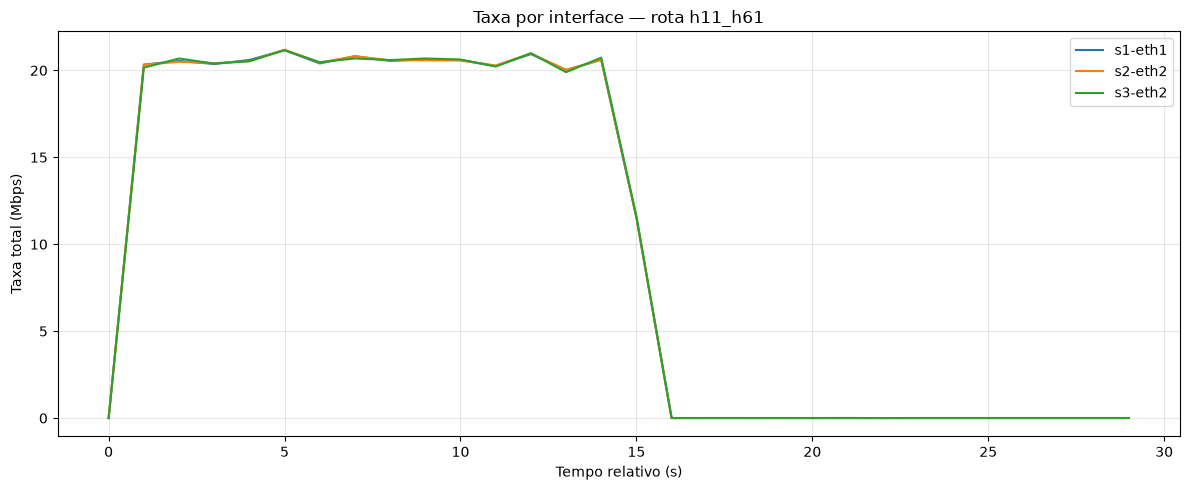

In [23]:
rota_para_validar = 'h11_h61'
por_interface = fg_banda_interface[fg_banda_interface.rota_id == rota_para_validar]

fig = plt.figure(figsize=(12, 5))
for interface, grupo in por_interface.groupby('interface'):
    tempo = grupo.ts_epoch - view.ts_epoch.min()
    plt.plot(tempo, grupo.taxa_Mbps, label=interface, linewidth=1.5)

plt.legend()
plt.xlabel('Tempo relativo (s)')
plt.ylabel('Taxa total (Mbps)')
plt.title(f'Taxa por interface — rota {rota_para_validar}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

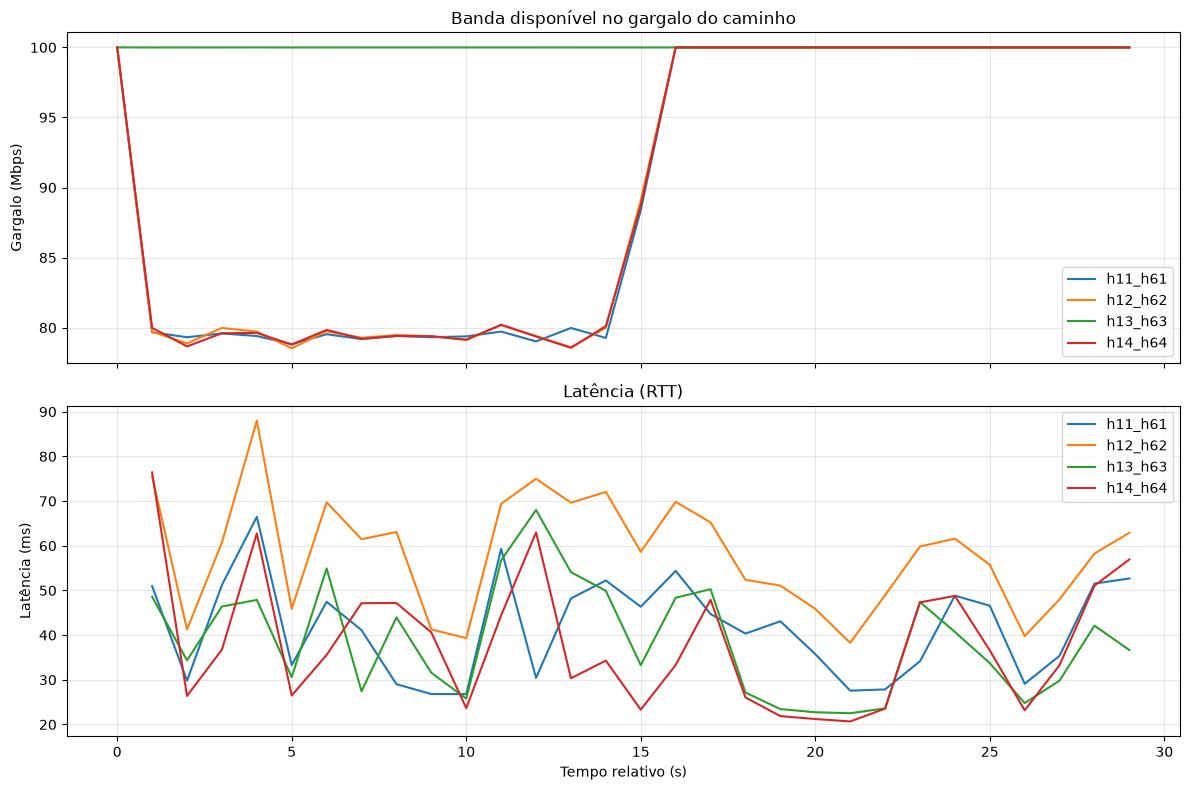

In [24]:
# Contraste entre as rotas: gargalo e latência
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for rota, grupo in view.groupby('rota_id'):
    axes[0].plot(grupo.tempo_relativo_s, grupo.gargalo_Mbps, label=rota, linewidth=1.5)
    axes[1].plot(grupo.tempo_relativo_s, grupo.latencia_ms, label=rota, linewidth=1.5)

axes[0].set_ylabel('Gargalo (Mbps)')
axes[0].set_title('Banda disponível no gargalo do caminho')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('Latência (ms)')
axes[1].set_xlabel('Tempo relativo (s)')
axes[1].set_title('Latência (RTT)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

No painel superior, a rota `h13_h63` mantém-se em 100 Mbps, enquanto as demais
decaem para aproximadamente 80 Mbps. O comportamento constitui a assinatura da
contenção de enlaces compartilhados, sinal que se perdia enquanto as duas fontes
permaneciam desalinhadas.

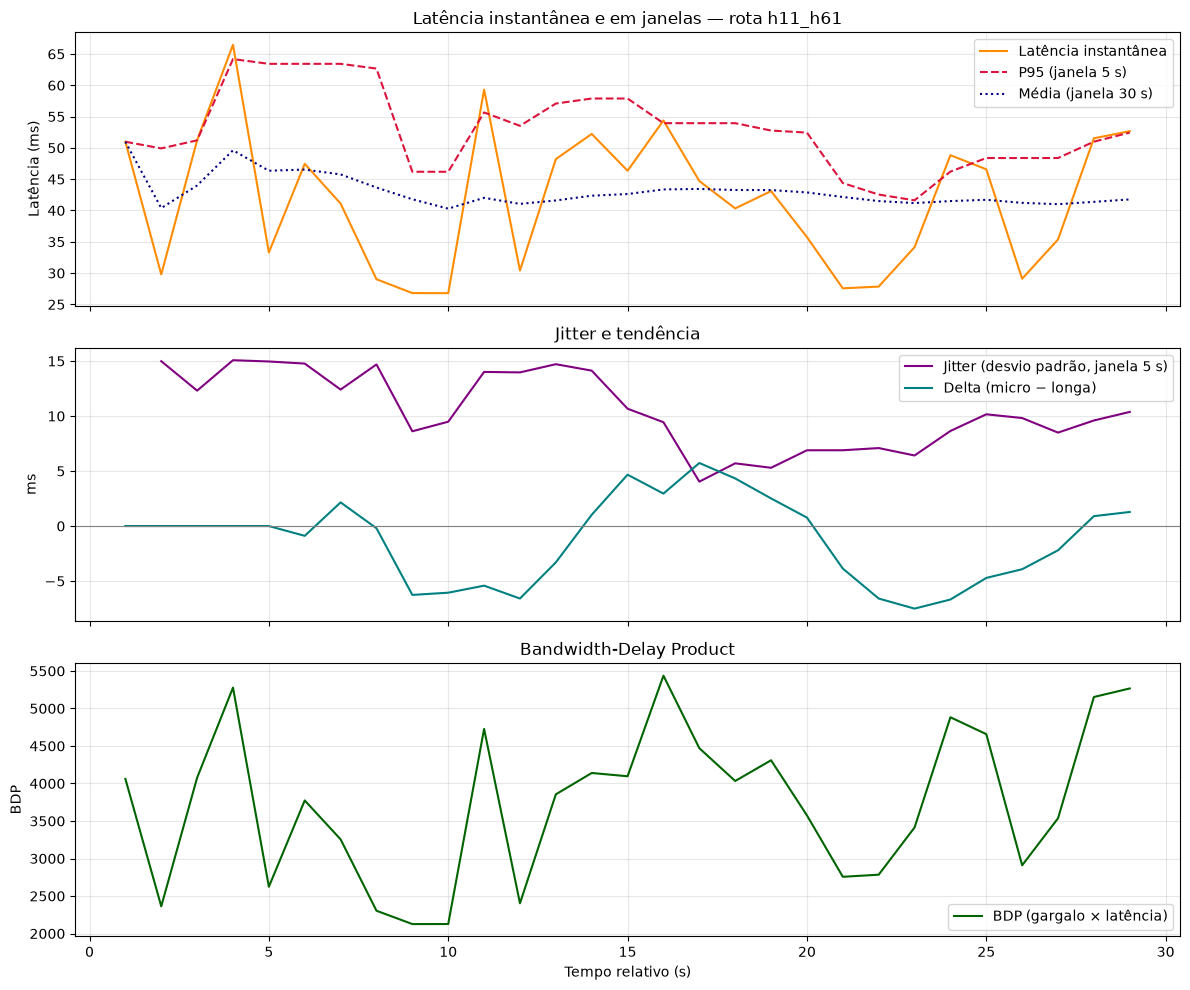

In [25]:
# Features derivadas: valor instantâneo frente às janelas, jitter, tendência e BDP
da_rota = view[view.rota_id == rota_para_validar]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(da_rota.tempo_relativo_s, da_rota.latencia_ms,
             label='Latência instantânea', color='darkorange')
axes[0].plot(da_rota.tempo_relativo_s, da_rota.latencia_p95_micro_5s,
             label='P95 (janela 5 s)', color='crimson', linestyle='--')
axes[0].plot(da_rota.tempo_relativo_s, da_rota.latencia_media_longa_30s,
             label='Média (janela 30 s)', color='navy', linestyle=':')
axes[0].set_ylabel('Latência (ms)')
axes[0].set_title(f'Latência instantânea e em janelas — rota {rota_para_validar}')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(da_rota.tempo_relativo_s, da_rota.latencia_jitter_micro_5s,
             label='Jitter (desvio padrão, janela 5 s)', color='purple')
axes[1].plot(da_rota.tempo_relativo_s, da_rota.latencia_delta_micro_longa,
             label='Delta (micro − longa)', color='teal')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_ylabel('ms')
axes[1].set_title('Jitter e tendência')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(da_rota.tempo_relativo_s, da_rota.bdp,
             label='BDP (gargalo × latência)', color='darkgreen')
axes[2].set_ylabel('BDP')
axes[2].set_xlabel('Tempo relativo (s)')
axes[2].set_title('Bandwidth-Delay Product')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Consulta à store

A função `get_features` recupera a tabela persistida e retorna o subconjunto de
features solicitado. A solicitação restrita a `('latencia',)` reproduz o
conjunto de preditores dos `datasets/D*`, o que permite comparar essa linha de
base com o conjunto que incorpora a banda sem manutenção de pipelines
independentes.

In [26]:
print("linha de base (somente latência):")
print(f"  {list(fs.get_features(metricas=('latencia',)).columns)}")
print()
print("somente banda:")
print(f"  {list(fs.get_features(metricas=('banda',)).columns)}")
print()
completo = fs.get_features()
print(f"conjunto completo: {completo.shape[1]} colunas, {len(completo)} registros")

linha de base (somente latência):
  ['run_id', 'rota_id', 'ts_epoch', 'datetime_utc', 'tempo_relativo_s', 'latencia_ms', 'latencia_p95_micro_5s', 'latencia_jitter_micro_5s', 'latencia_media_micro_5s', 'latencia_p95_curta_15s', 'latencia_jitter_curta_15s', 'latencia_media_curta_15s', 'latencia_p95_longa_30s', 'latencia_jitter_longa_30s', 'latencia_media_longa_30s', 'latencia_delta_micro_longa', 'melhor_rota']

somente banda:
  ['run_id', 'rota_id', 'ts_epoch', 'datetime_utc', 'tempo_relativo_s', 'gargalo_Mbps', 'banda_media_Mbps', 'util_max_pct', 'gargalo_min_micro_5s', 'banda_media_micro_5s', 'utilizacao_media_micro_5s', 'gargalo_min_curta_15s', 'banda_media_curta_15s', 'utilizacao_media_curta_15s', 'gargalo_min_longa_30s', 'banda_media_longa_30s', 'utilizacao_media_longa_30s', 'melhor_rota']

conjunto completo: 31 colunas, 120 registros


In [27]:
# Filtro por rota e por janela temporal
fs.get_features(
    rotas=['h11_h61', 'h13_h63'],
    inicio='2026-08-18 02:13:35',
    fim='2026-08-18 02:13:38',
)[['datetime_utc', 'rota_id', 'latencia_ms', 'gargalo_Mbps', 'bdp', 'melhor_rota']]

,datetime_utc,rota_id,latencia_ms,gargalo_Mbps,bdp,melhor_rota
0,2026-08-18 02:13:35,h11_h61,33.287741,78.814240,2623.547984,4
1,2026-08-18 02:13:35,h13_h63,30.589982,99.996080,3058.878281,4
2,2026-08-18 02:13:36,h11_h61,47.454748,79.530688,3774.108762,4
3,2026-08-18 02:13:36,h13_h63,54.920842,99.995520,5491.838107,4
4,2026-08-18 02:13:37,h11_h61,41.105758,79.184544,3254.940729,3
5,2026-08-18 02:13:37,h13_h63,27.435399,99.996080,2743.432391,3
6,2026-08-18 02:13:38,h11_h61,29.014412,79.408558,2303.992583,1
7,2026-08-18 02:13:38,h13_h63,43.969239,99.996873,4396.786399,1


## 13. Limitações desta coleta

**Volume.** A execução válida compreende 30 s úteis, correspondentes a 120
registros (30 s × 4 rotas). O conjunto é suficiente para validar o pipeline e
evidenciar o efeito da contenção, mas não para treinar um modelo. Resultados de
aprendizado de máquina não devem ser derivados da store em sua configuração
atual.

**Janela longa.** Conforme exposto na Seção 7, a janela de 30 s abrange todo o
experimento e não constitui linha de base histórica.

**Vazamento no alvo.** A coluna `melhor_rota` é função determinística da
latência, conforme demonstrado na Seção 7 para os dez conjuntos de dados
existentes.

**Extensão prevista.** Os conjuntos em `datasets/D*` dispõem de cerca de uma
hora de coleta cada (3600 a 3850 s), com `banda.bwm` cobrindo continuamente as
31 interfaces, sob topologia idêntica à desta coleta — mesmos quatro caminhos e
mesmo `config.json`. Sua ingestão elevaria o conjunto a aproximadamente 36 mil
registros. As funções de `pipeline.py` recebem `pasta_relatorios` e
`caminho_config` como parâmetros precisamente para viabilizar essa extensão sem
reescrita, ainda que `banda.bwm` demande um leitor próprio, dado que agrega
todas as interfaces em um único arquivo, em vez de um arquivo por rota.